# AG-HYPOPT · Trial 22

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-one trials are registered; cell 2 reports `phase = trials` (21/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074 — a new best found in the last round, beating trial_08's 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** `lr_mu=0.1669`, `mu_anneal=0.3455` (travel 0.138), `lr_gamma=0.4716`, `gamma_anneal=0.4723` (balanced gamma). 0 div.
- **trial_08 (0.1099), trial_15 (0.1103), trial_16 (0.1112), trial_12 (0.1115), trial_18 (0.1121):** travels 0.134 / 0.127 / 0.128 / 0.128 / 0.138; 0 div.
- rest of the plateau: trial_09 = trial_20 0.1126, trial_01 = trial_14 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_06 0.1188.
- diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: trial_21 broke the plateau — same optimum travel as trial_08 (0.138) but with a balanced gamma schedule (`lr_gamma≈gamma_anneal≈0.47`), improving several cells at once. This is the first new best since trial_08. The optimum band (travel 0.12-0.14) with mid-range gamma knobs remains the productive region; low travel (<0.10) is worse and the source of sporadic divergences. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_22'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (21/5 trials)
ID |     ei | params
 1 | 0.4600 | {"gamma_anneal": 0.4270691689725522, "lr_gamma": 0.670532103220874, "lr_mu": 0.08691227387293646, "mu_anneal": 0.35810707862555746}
 2 | 2.9065 | {"gamma_anneal": 0.49981063982538654, "lr_gamma": 0.4292948621865119, "lr_mu": 0.1160234678216075, "mu_anneal": 0.3428342038972034}
 3 | 0.9013 | {"gamma_anneal": 0.41594932132170453, "lr_gamma": 0.46096226114568506, "lr_mu": 0.09027762155198478, "mu_anneal": 0.5121715583946574}
 4 | 3.7925 | {"gamma_anneal": 0.48891779781375766, "lr_gamma": 0.453941403688717, "lr_mu": 0.14257985873833554, "mu_anneal": 0.3440869065715815}
 5 | 3.0326 | {"gamma_anneal": 0.634131258825486, "lr_gamma": 0.46714960366613273, "lr_mu": 0.09295123275060099, "mu_anneal": 0.348829038489897}
 6 | 3.5576 | {"gamma_anneal": 0.5414547529378313, "lr_gamma": 0.46634608817292134, "lr_mu": 0.17676231808750525, "mu_anneal": 0.3587620262267738}
 7 | 3.9181 | {"gamma_anneal": 0.4882206519882266, "lr_gamma": 0.456887

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (21 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 7: **ei 3.92** — `lr_mu=0.166`, `mu_anneal=0.349` (travel **0.137**), `lr_gamma=0.457`, `gamma_anneal=0.488`.
- candidate 4: ei 3.79 — `lr_mu=0.143`, `mu_anneal=0.344` (travel 0.118), `lr_gamma=0.454`, `gamma_anneal=0.489`.
- candidate 6: ei 3.56 — `lr_mu=0.177`, `mu_anneal=0.359` (travel 0.145), `lr_gamma=0.466`, `gamma_anneal=0.541`.
- candidate 5: ei 3.03 — `lr_mu=0.093`, `mu_anneal=0.349` (travel 0.077, low), `lr_gamma=0.467`.
- candidate 2: ei 2.91 — `lr_mu=0.116`, `mu_anneal=0.343` (travel 0.096), `lr_gamma=0.429`.

Candidate 7 has the highest ei and is placed right on the new best: travel 0.137 (trial_21's 0.138), with `lr_gamma=0.457`/`gamma_anneal=0.488` very close to the balanced schedule that just produced 0.1074. It is the natural follow-up — a slightly different point in the exact neighbourhood that just improved the best. The other candidates are similar optimum resamples (candidate 4 at 0.118, candidate 6 at 0.145) or worse low-travel points (candidate 5 at 0.077). So the maximum-ei candidate 7 is also the best-supported.

I choose candidate 7 (7 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4882206519882266, 'lr_gamma': 0.4568877930333853, 'lr_mu': 0.1658462284704711, 'mu_anneal': 0.3487087177212092}
Running  1nW Trans05 ... 

μ 9.39 -> 11.16 | γ 8.5 -> 4.54 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 42.97 | γ 8.5 -> 6.23 | NLL 5.48


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 80.02 | γ 14.1 -> 14.53 | NLL 3.18


Running 3nW Trans100 ... 

μ 175.71 -> 110.19 | γ 14.1 -> 14.13 | NLL 3.62



Total: 8.4 min


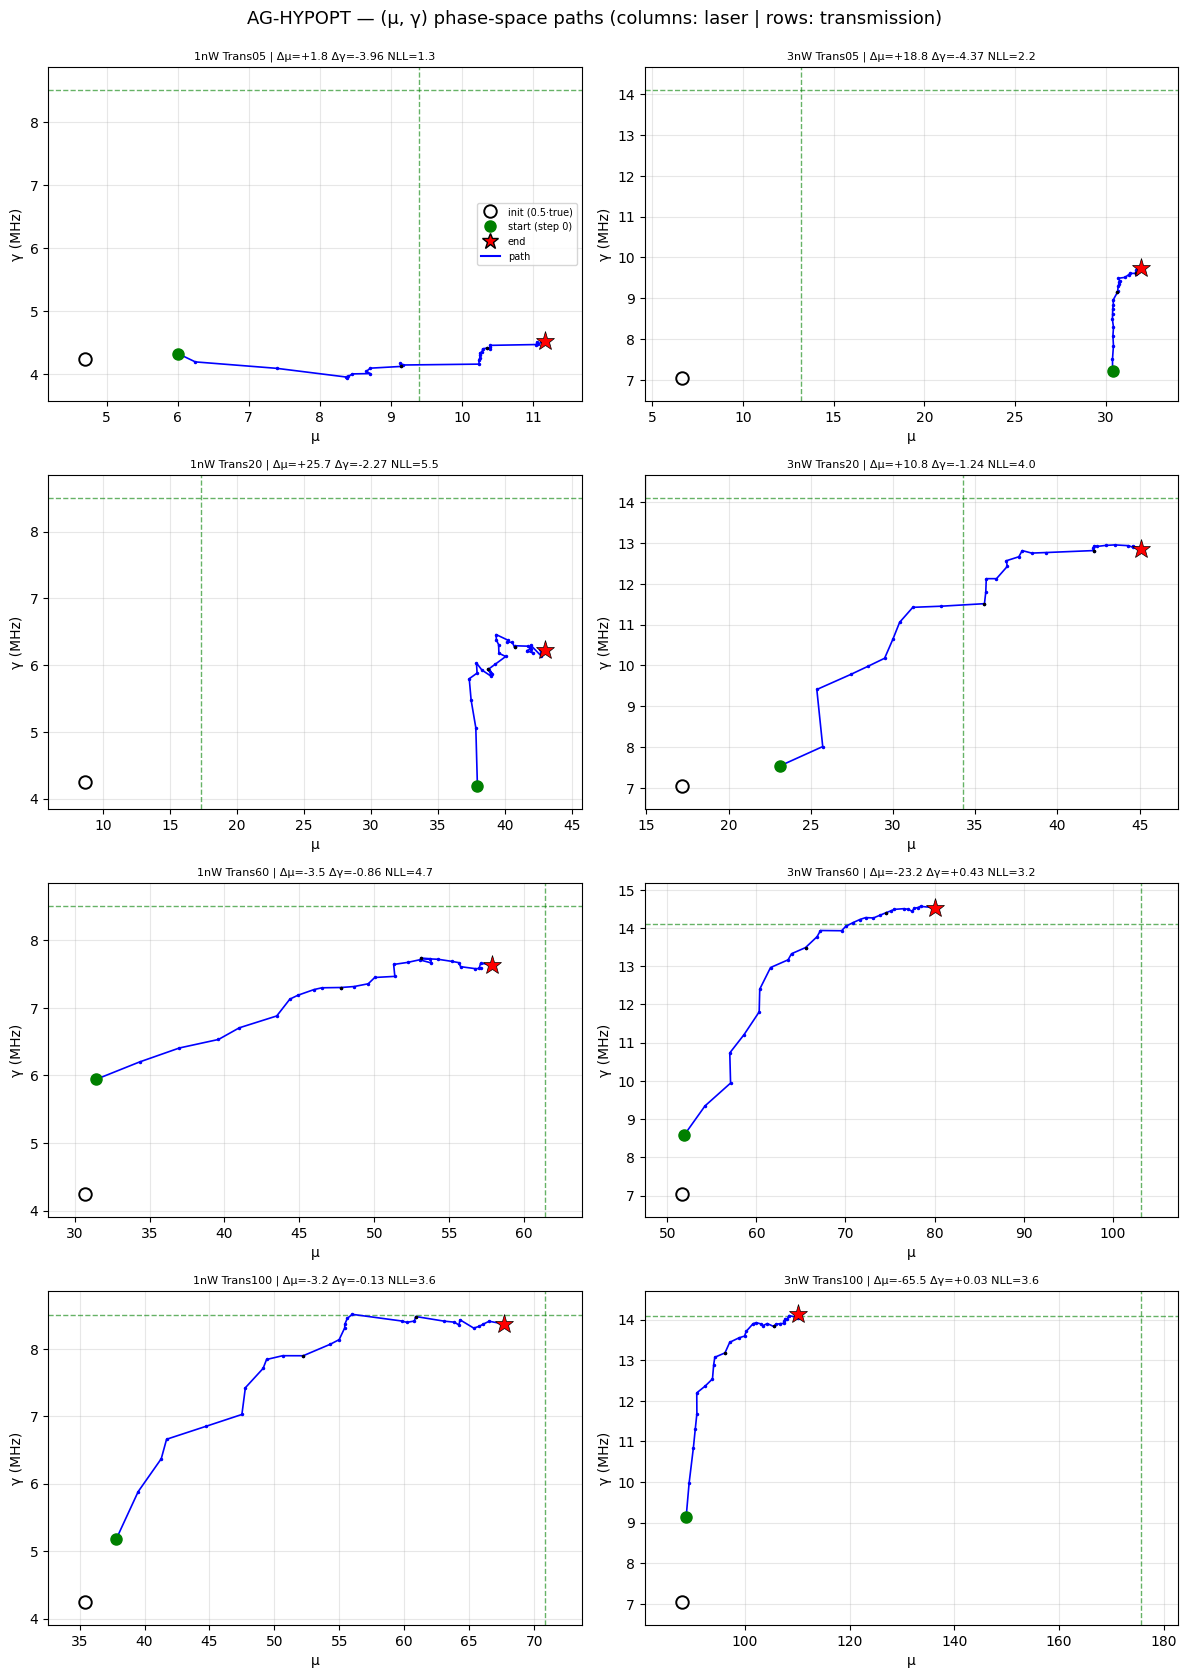

trial finished in 8.4 min
objective = 0.1095 ± 0.0824
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   11.16   +18.8 |     8.50    4.54   -46.6
1nW Trans20       17.32   42.97  +148.1 |     8.50    6.23   -26.8
1nW Trans60       61.37   57.84    -5.8 |     8.50    7.64   -10.1
1nW Trans100       70.82   67.65    -4.5 |     8.50    8.37    -1.6
3nW Trans05       13.20   31.97  +142.1 |    14.10    9.73   -31.0
3nW Trans20       34.28   45.11   +31.6 |    14.10   12.86    -8.8
3nW Trans60      103.20   80.02   -22.5 |    14.10   14.53    +3.0
3nW Trans100      175.71  110.19   -37.3 |    14.10   14.13    +0.2

weighted objective (T-graded, cap=1.0) = 0.1095 | diverged cells: 0
μ: RMSE 27.349 (rel 75.4%, bias -4.799) | γ: RMSE 2.303 (rel 22.5%, bias -1.547)


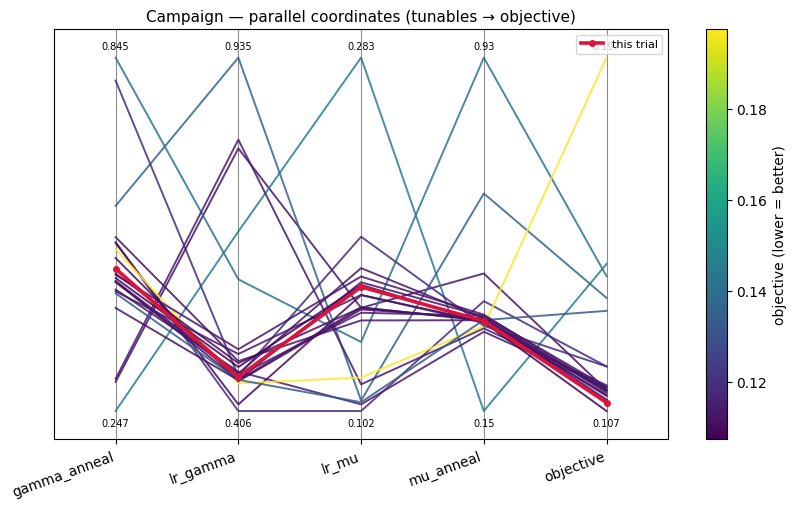

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 22 ran the highest-EI candidate (candidate 7, ei=3.92): `lr_mu=0.1658`, `mu_anneal=0.3487` (effective mu travel 0.137), `lr_gamma=0.4569`, `gamma_anneal=0.4882`. It completed in 8.4 min with objective **0.1095 +/- 0.0824** and **0 diverged cells** — second-best. Ranking: trial_21 0.1074 < **trial_22 0.1095** < trial_08 0.1099 < trial_15 0.1103 < trial_16 0.1112 < trial_12 0.1115 < trial_18 0.1121 < ...

Aggregate accuracy: **mu rel-RMSE 75.4%** (RMSE 27.35, bias -4.80); **gamma rel-RMSE 22.5%** (RMSE 2.30, bias -1.55).

Per-cell relative errors:
- **mu:** 1nW T05 +18.8%, T20 +148.1%, T60 -5.8%, T100 -4.5% | 3nW T05 +142.1%, T20 +31.6%, T60 -22.5%, T100 -37.3%.
- **gamma:** 1nW T05 -46.6%, T20 -26.8%, T60 -10.1%, T100 -1.6% | 3nW T05 -31.0%, T20 -8.8%, T60 +3.0%, T100 +0.2%.

A near-neighbour of the new best (travel 0.137 vs trial_21's 0.138, gamma knobs close), divergence-free, landing at 0.1095 — second-best and above trial_08 but below trial_21. It confirms the neighbourhood of trial_21 as the campaign's best region (two of the three best runs are here) while showing trial_21's exact point remains the lowest. The differences are in the small cells: trial_22 is slightly worse at 1nW T60 (-5.8% vs trial_21's -2.9%) and 3nW T05 (+142.1% vs +146.0% is marginally better), netting a small deficit.

**Summary:** Trial 22 (lr_mu=0.1658, mu_anneal=0.3487, lr_gamma=0.4569, gamma_anneal=0.4882): objective 0.1095 +/- 0.0824 with 0 diverged cells; a near-neighbour of the new best (travel 0.137) landed second-best but did not beat trial_21 (0.1074), so trial_21 stays best.
**Key insight:** The trial_21 neighbourhood (travel ~0.137, balanced gamma ~0.46-0.49) is confirmed as the campaign's best region - two of the three best runs sit here - but trial_21's exact point remains the lowest at 0.1074.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The new best (trial_21) and its neighbour share the same residual pattern; the gain seems to come from a balanced gamma schedule at travel ~0.138. A few more samples in this exact neighbourhood are the best remaining use of the campaign. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 22 (lr_mu=0.1658, mu_anneal=0.3487, lr_gamma=0.4569, gamma_anneal=0.4882): objective 0.1095 +/- 0.0824 with 0 diverged cells; a near-neighbour of the new best (travel 0.137) landed second-best but did not beat trial_21 (0.1074), so trial_21 stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The trial_21 neighbourhood (travel ~0.137, balanced gamma ~0.46-0.49) is confirmed as the campaign's best region - two of the three best runs sit here - but trial_21's exact point remains the lowest at 0.1074"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_22 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_23.ipynb. Open it and follow its cells from the top.
